# PresyoPH – Model Building (Task 3)

Builds the CPI forecasting models on the training data and produces their forecasts for the test period. Scoring the forecasts (MAE, RMSE, MAPE), selecting the final model, and the rolling-origin check are task 4.

**Models**

| Model | Status | Setup |
|---|---|---|
| ARIMA | in the proposal | ARIMA(p, 1, q) with drift; p, q ∈ {0, 1, 2}; one seasonal candidate; chosen by AIC with a parsimony rule |
| Linear Regression | in the proposal | CPI on a time index (overall trend), OLS |
| Moving Average | in the proposal | flat mean of the last *k* months; k ∈ {3, 6, 12} chosen on a validation window |
| ETS | **extra, not in the proposal** | Holt's method (additive trend, damped or not), chosen by AIC with a parsimony rule |

All settings come from `modeling/config.py`; the models are in `modeling/models.py`. Every model is tuned on the training data only.

**Split:** train Jan 2018 – Aug 2025 (92 months), test Sep 2025 – Aug 2026 (12 months).

In [14]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf

from modeling import config
from modeling.temp_loader import load_cpi, load_inflation, load_purchasing_power
from modeling.derive import derive_all
from modeling.models import fit_all

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", "{:.4f}".format)

COLORS = {"ARIMA": "tab:blue", "Linear Regression": "tab:orange", "Moving Average": "tab:green", "ETS": "tab:purple"}

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## 1. Train/test split

Train: Jan 2018 – Aug 2025  (92 months)
Test:  Sep 2025 – Aug 2026  (12 months)
Split: 88.5% / 11.5%


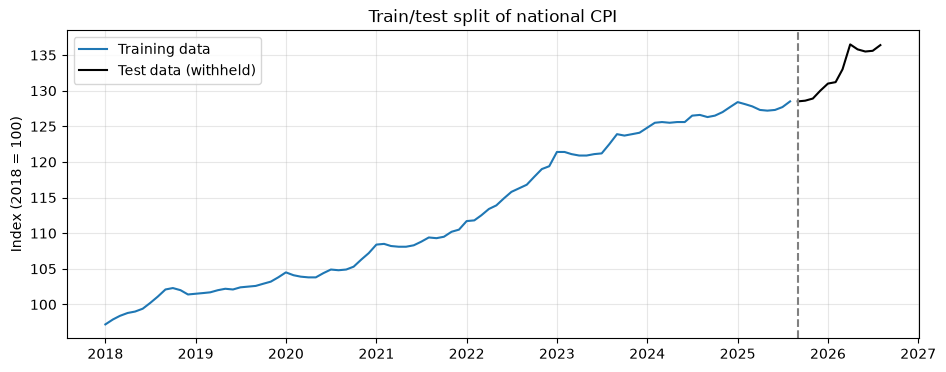

In [15]:
cpi = load_cpi()
train = cpi[: config.TRAIN_END]
test = cpi[config.TEST_START : config.TEST_END]

print(f"Train: {train.index[0]:%b %Y} – {train.index[-1]:%b %Y}  ({len(train)} months)")
print(f"Test:  {test.index[0]:%b %Y} – {test.index[-1]:%b %Y}  ({len(test)} months)")
print(f"Split: {len(train) / len(cpi):.1%} / {len(test) / len(cpi):.1%}")

fig, ax = plt.subplots()
ax.plot(train, label="Training data")
ax.plot(test, color="black", label="Test data (withheld)")
ax.axvline(config.TEST_START, color="grey", linestyle="--")
ax.set_title("Train/test split of national CPI")
ax.set_ylabel("Index (2018 = 100)")
ax.legend()
save(fig, "08_train_test_split")
plt.show()

## 2. Fit all models on the training data

In [16]:
results = fit_all(train, horizon=config.HORIZON)
{name: r.params for name, r in results.items()}

{'ARIMA': {'order': (1, 1, 0),
  'seasonal_order': (0, 0, 0, 0),
  'aic': np.float64(116.71447207470338),
  'drift_per_month': 0.34872799415779626},
 'Linear Regression': {'intercept': np.float64(95.36696129957005),
  'slope_per_month': np.float64(0.37511443675538925),
  'r_squared': np.float64(0.9678635069527868)},
 'Moving Average': {'k': 3, 'level': np.float64(127.83333333333333)},
 'ETS': {'damped_trend': False,
  'aic': np.float64(134.3556042470694),
  'smoothing_level': 0.9999,
  'smoothing_trend': 0.08803081379395694}}

## 3. ARIMA

**Selection.** All 18 candidates (p, q ∈ {0, 1, 2}, with and without a seasonal AR term) are ranked by AIC. Candidates within 2 AIC points of the best are treated as equally supported, and the one with the fewest parameters is chosen (Burnham & Anderson, 2002).

In [17]:
results["ARIMA"].candidates

,order,seasonal_order,aic,n_params,converged,delta_aic,selected
0,"(0, 1, 1)","(1, 0, 0, 12)",115.6773,4,True,0.0000,False
1,"(1, 1, 0)","(0, 0, 0, 0)",116.7145,3,True,1.0372,True
2,"(1, 1, 0)","(1, 0, 0, 12)",116.7193,4,True,1.0420,False
3,"(0, 1, 1)","(0, 0, 0, 0)",116.7736,3,True,1.0963,False
4,"(1, 1, 1)","(1, 0, 0, 12)",117.6649,5,True,1.9876,False
5,"(0, 1, 2)","(1, 0, 0, 12)",117.6748,5,True,1.9976,False
6,"(2, 1, 0)","(1, 0, 0, 12)",117.7275,5,True,2.0502,False
7,"(2, 1, 2)","(0, 0, 0, 0)",117.7752,6,True,2.0979,False
8,"(2, 1, 0)","(0, 0, 0, 0)",118.1945,4,True,2.5172,False
9,"(1, 1, 1)","(0, 0, 0, 0)",118.3388,4,True,2.6615,False


In [18]:
arima = results["ARIMA"]
print(arima.fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                    cpi   No. Observations:                   92
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 -55.357
Date:                Thu, 01 Oct 2026   AIC                            116.714
Time:                        12:31:18   BIC                            124.247
Sample:                    01-01-2018   HQIC                           119.753
                         - 08-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.3487      0.081      4.304      0.000       0.190       0.508
ar.L1          0.3513      0.090      3.901      0.000       0.175       0.528
sigma2         0.1974      0.026      7.525      0.0

**Residual diagnostics.** A good ARIMA model leaves residuals that look like random noise: no autocorrelation (Ljung–Box p > 0.05), centred on zero, and roughly normal. The first residual is dropped because it reflects the differencing start-up, not a real forecast error.

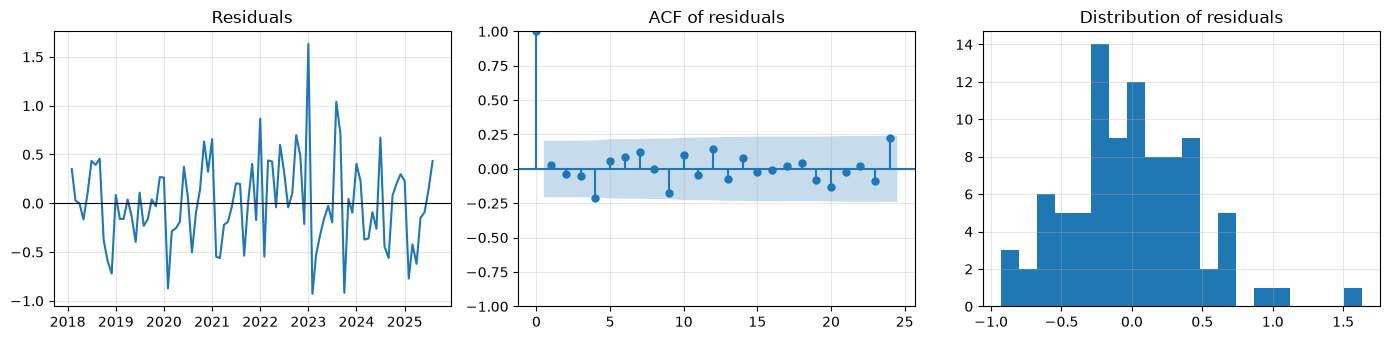

,lb_stat,lb_pvalue
6,5.8738,0.4375
12,14.1351,0.2922
24,25.8008,0.3634


In [19]:
resid = arima.fitted.resid.iloc[1:]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(resid)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Residuals")
plot_acf(resid, lags=24, ax=axes[1], title="ACF of residuals")
axes[2].hist(resid, bins=20)
axes[2].set_title("Distribution of residuals")
fig.tight_layout()
save(fig, "09_arima_residuals")
plt.show()

acorr_ljungbox(resid, lags=[6, 12, 24], return_df=True)

## 4. Linear Regression

CPI regressed on a time index (1, 2, …, 92). The slope is the average CPI increase per month over the whole training period.

The Durbin–Watson statistic checks one of OLS's assumptions: that residuals are independent. Values near 2 mean independent; values near 0 mean strong positive autocorrelation, which is typical when a straight line is fitted to a time series.

CPI = 95.367 + 0.3751 × t   (R² = 0.968)
Durbin–Watson statistic of residuals: 0.068


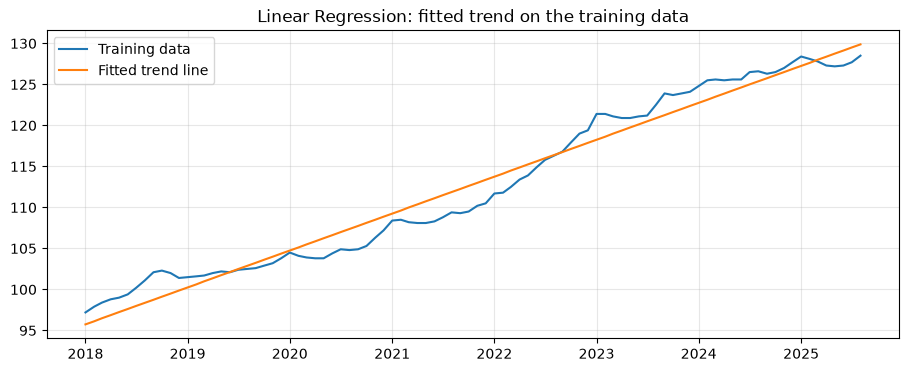

In [20]:
lr = results["Linear Regression"]
print(f"CPI = {lr.params['intercept']:.3f} + {lr.params['slope_per_month']:.4f} × t   (R² = {lr.params['r_squared']:.3f})")
print(f"Durbin–Watson statistic of residuals: {durbin_watson(lr.fitted.resid):.3f}")

t = np.arange(1, len(train) + 1)
fig, ax = plt.subplots()
ax.plot(train, label="Training data")
ax.plot(train.index, lr.fitted.fittedvalues, color=COLORS["Linear Regression"], label="Fitted trend line")
ax.set_title("Linear Regression: fitted trend on the training data")
ax.legend()
save(fig, "10_linear_regression_fit")
plt.show()

## 5. Moving Average

The window *k* is chosen on a validation window — the last 12 training months (Sep 2024 – Aug 2025) — by forecasting it from the data before it. The test set is not used. The final forecast is the mean of the last *k* training months, held flat for all 12 months.

Prediction intervals come from this method's past forecast errors at each step ahead (empirical quantiles), since a moving average has no statistical model to derive them from.

In [21]:
ma = results["Moving Average"]
print(f"Chosen window: k = {ma.params['k']}  →  forecast level {ma.params['level']:.2f}")
ma.candidates

Chosen window: k = 3  →  forecast level 127.83


,k,validation_rmse
0,3,1.4126
1,6,1.7146
2,12,2.4645


## 6. ETS (extra – not in the proposal)

Holt's exponential smoothing with additive errors and trend, with and without a damped trend, chosen by AIC with the same parsimony rule as ARIMA. It is reported for comparison and is not eligible for selection unless the instructor approves adding it.

In [22]:
ets = results["ETS"]
print({k: v for k, v in ets.params.items()})
ets.candidates

{'damped_trend': False, 'aic': np.float64(134.3556042470694), 'smoothing_level': 0.9999, 'smoothing_trend': 0.08803081379395694}


,damped_trend,aic,n_params,converged,delta_aic,selected
0,False,134.3556,4,True,0.0000,True
1,True,135.8992,5,True,1.5436,False


## 7. Test-period forecasts

Each model forecasts the 12 test months from the end of the training data (Aug 2025). Shaded bands are 95% prediction intervals.

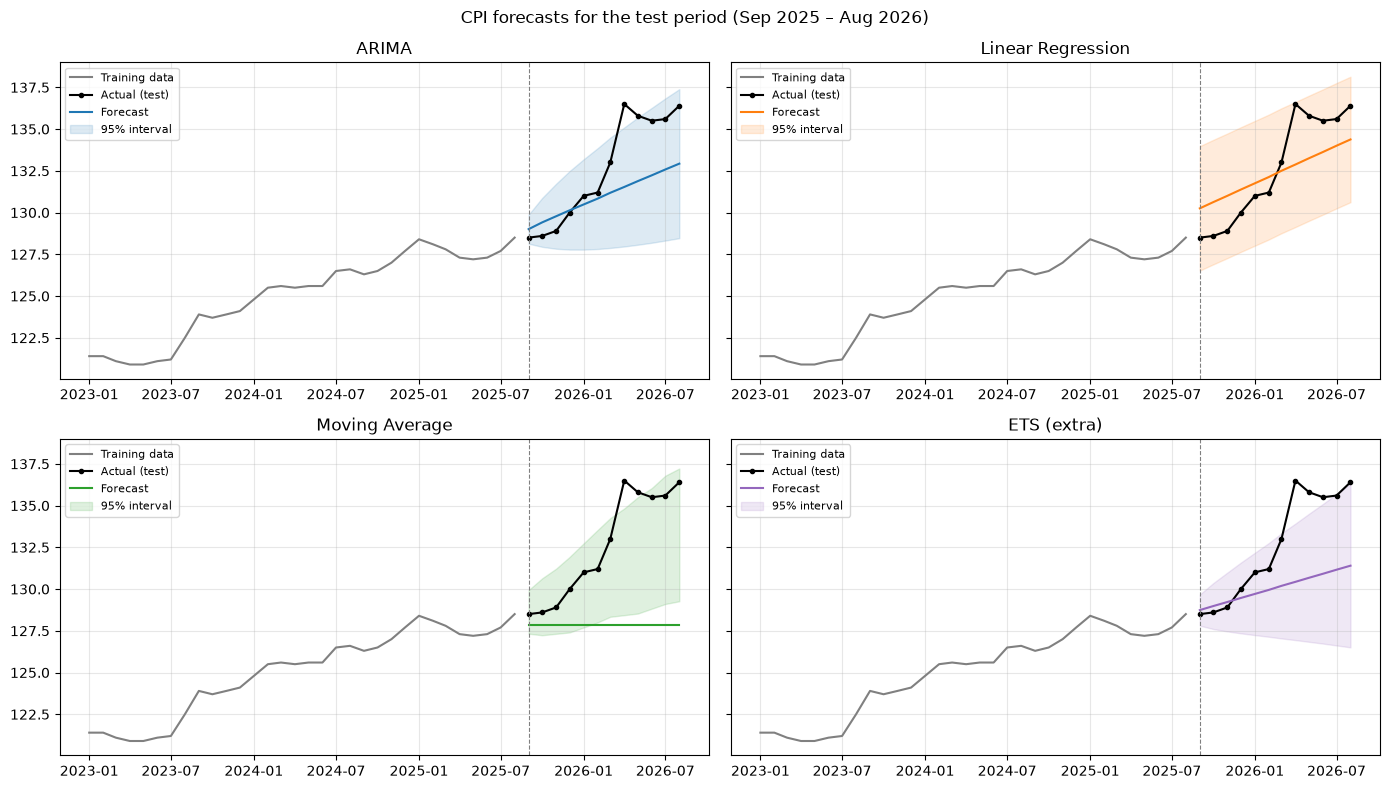

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
history = cpi["2023-01":config.TRAIN_END]
for ax, (name, r) in zip(axes.flat, results.items()):
    ax.plot(history, color="grey", label="Training data")
    ax.plot(test, color="black", marker="o", markersize=3, label="Actual (test)")
    ax.plot(r.forecast, color=COLORS[name], label="Forecast")
    ax.fill_between(r.forecast.index, r.lower, r.upper, color=COLORS[name], alpha=0.15, label="95% interval")
    ax.axvline(config.TEST_START, color="grey", linestyle="--", linewidth=0.8)
    ax.set_title(name + (" (extra)" if name in config.EXTRA_MODELS else ""))
    ax.legend(fontsize=8, loc="upper left")
fig.suptitle("CPI forecasts for the test period (Sep 2025 – Aug 2026)")
fig.tight_layout()
save(fig, "11_test_forecasts_by_model")
plt.show()

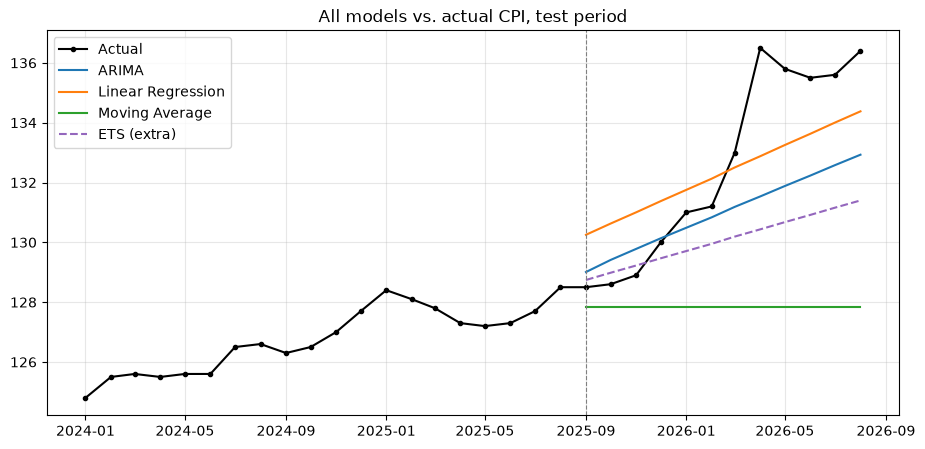

,actual,ARIMA,Linear Regression,Moving Average,ETS
2025-09-01,128.5000,129.0100,130.2500,127.8300,128.7400
2025-10-01,128.6000,129.4100,130.6300,127.8300,128.9800
2025-11-01,128.9000,129.7800,131.0000,127.8300,129.2300
2025-12-01,130.0000,130.1400,131.3800,127.8300,129.4700
2026-01-01,131.0000,130.4900,131.7500,127.8300,129.7100
2026-02-01,131.2000,130.8400,132.1300,127.8300,129.9500
2026-03-01,133.0000,131.1900,132.5000,127.8300,130.1900
2026-04-01,136.5000,131.5300,132.8800,127.8300,130.4300
2026-05-01,135.8000,131.8800,133.2500,127.8300,130.6800
2026-06-01,135.5000,132.2300,133.6300,127.8300,130.9200


In [24]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cpi["2024-01":], color="black", marker="o", markersize=3, label="Actual")
for name, r in results.items():
    ax.plot(r.forecast, color=COLORS[name], linestyle="--" if name in config.EXTRA_MODELS else "-",
            label=name + (" (extra)" if name in config.EXTRA_MODELS else ""))
ax.axvline(config.TEST_START, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("All models vs. actual CPI, test period")
ax.legend()
save(fig, "12_test_forecasts_all")
plt.show()

forecast_table = pd.DataFrame({"actual": test, **{name: r.forecast for name, r in results.items()}})
forecast_table.round(2)

Supporting numbers for the notes: how each forecast compares with the actual test values, how wide each 95% interval is at the first and last step, and how many actual months fall inside it.

In [25]:
print(f"Average monthly CPI change over the training period: {train.diff().mean():.3f} index points")

rows = {}
for name, r in results.items():
    inside = (test >= r.lower) & (test <= r.upper)
    rows[name] = {
        "forecast change / month": (r.forecast.iloc[-1] - r.forecast.iloc[0]) / (len(r.forecast) - 1),
        "first-month error (actual − forecast)": test.iloc[0] - r.forecast.iloc[0],
        "interval width, month 1": r.upper.iloc[0] - r.lower.iloc[0],
        "interval width, month 12": r.upper.iloc[-1] - r.lower.iloc[-1],
        "actual months inside 95% interval": f"{inside.sum()} of {len(test)}",
        "months outside": ", ".join(test.index[~inside].strftime("%b %Y")) or "none",
    }
pd.DataFrame(rows).T

Average monthly CPI change over the training period: 0.344 index points


,forecast change / month,first-month error (actual − forecast),"interval width, month 1","interval width, month 12",actual months inside 95% interval,months outside
ARIMA,0.3565,-0.5073,1.7415,8.9268,10 of 12,"Apr 2026, May 2026"
Linear Regression,0.3751,-1.7526,7.4516,7.5142,12 of 12,none
Moving Average,0.0000,0.6667,2.6133,7.9517,10 of 12,"Apr 2026, May 2026"
ETS,0.2417,-0.2416,1.8645,9.7841,8 of 12,"Apr 2026, May 2026, Jun 2026, Aug 2026"


## 8. Derived inflation and purchasing power (option B)

Each model's CPI forecast is converted into inflation and purchasing power with PSA's formulas (`modeling/derive.py`). For inflation, CPI twelve months earlier comes from the actual data, so only the forecasted CPI is uncertain. These are compared with PSA's published series in task 4.

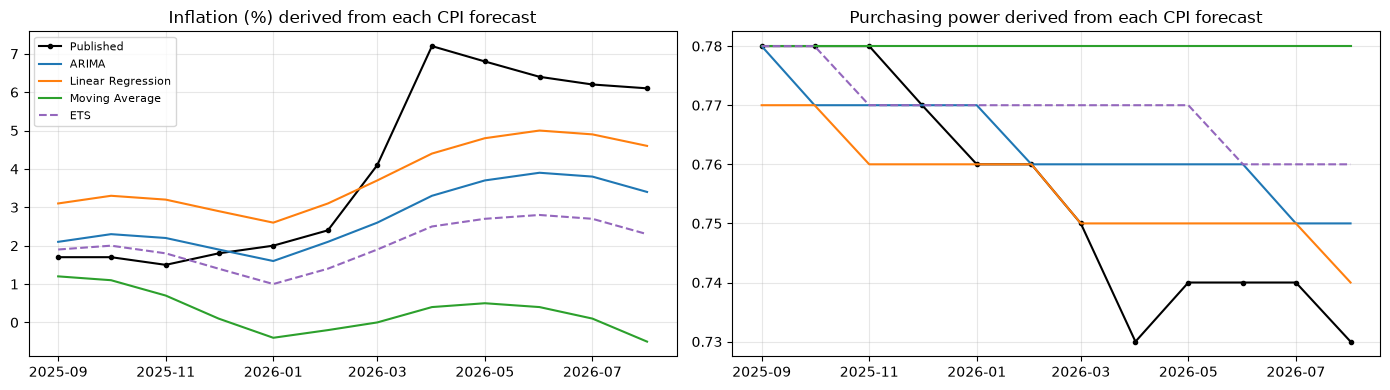

ARIMA                  Linear Regression                   \
           inflation purchasing_power         inflation purchasing_power   
2025-09-01    2.1000           0.7800            3.1000           0.7700   
2025-10-01    2.3000           0.7700            3.3000           0.7700   
2025-11-01    2.2000           0.7700            3.2000           0.7600   
2025-12-01    1.9000           0.7700            2.9000           0.7600   
2026-01-01    1.6000           0.7700            2.6000           0.7600   
2026-02-01    2.1000           0.7600            3.1000           0.7600   
2026-03-01    2.6000           0.7600            3.7000           0.7500   
2026-04-01    3.3000           0.7600            4.4000           0.7500   
2026-05-01    3.7000           0.7600            4.8000           0.7500   
2026-06-01    3.9000           0.7600            5.0000           0.7500   
2026-07-01    3.8000           0.7500            4.9000           0.7500   
2026-08-01    3.4000           0.7500            4.6000           0.7400   

           Moving Average                        ETS                   
                inflation purchasing_power inflation purchasing_power  
2025-09-01         1.2000           0.7800    1.9000           0.7800  
2025-10-01         1.1000           0.7800    2.0000           0.7800  
2025-11-01         0.7000           0.7800    1.8000           0.7700  
2025-12-01         0.1000           0.7800    1.4000           0.7700  
2026-01-01        -0.4000           0.7800    1.0000           0.7700  
2026-02-01        -0.2000           0.7800    1.4000           0.7700  
2026-03-01         0.0000           0.7800    1.9000           0.7700  
2026-04-01         0.4000           0.7800    2.5000           0.7700  
2026-05-01         0.5000           0.7800    2.7000           0.7700  
2026-06-01         0.4000           0.7800    2.8000           0.7600  
2026-07-01         0.1000           0.7800    2.7000           0.7600  
2026-08-01        -0.5000           0.7800    2.3000           0.7600

In [26]:
published_inf = load_inflation()[config.TEST_START : config.TEST_END]
published_pp = load_purchasing_power()[config.TEST_START : config.TEST_END]

derived = {name: derive_all(train, r.forecast) for name, r in results.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(published_inf, color="black", marker="o", markersize=3, label="Published")
axes[1].plot(published_pp, color="black", marker="o", markersize=3, label="Published")
for name, d in derived.items():
    style = "--" if name in config.EXTRA_MODELS else "-"
    axes[0].plot(d["inflation"], color=COLORS[name], linestyle=style, label=name)
    axes[1].plot(d["purchasing_power"], color=COLORS[name], linestyle=style, label=name)
axes[0].set_title("Inflation (%) derived from each CPI forecast")
axes[1].set_title("Purchasing power derived from each CPI forecast")
axes[0].legend(fontsize=8)
fig.tight_layout()
save(fig, "13_derived_forecasts")
plt.show()

pd.concat({name: d[["inflation", "purchasing_power"]] for name, d in derived.items()}, axis=1).round(2)

## 9. Tuning at each rolling-origin fold

For the rolling-origin check in task 4, every model is re-tuned at each origin using only the data up to that origin. This table shows the settings chosen at each fold and for the final refit on all data, to show how stable the tuning is.

In [27]:
rows = []
origins = list(config.ROLLING_ORIGINS) + [config.TRAIN_END, config.DATA_END]
labels = [f"fold {o:%b %Y}" for o in config.ROLLING_ORIGINS] + ["main test origin (Aug 2025)", "final refit (Aug 2026)"]
for label, origin in zip(labels, origins):
    fold = fit_all(cpi[:origin], horizon=config.HORIZON)
    rows.append({
        "origin": label,
        "train months": len(cpi[:origin]),
        "ARIMA order": fold["ARIMA"].params["order"],
        "ARIMA seasonal": fold["ARIMA"].params["seasonal_order"],
        "ARIMA drift / month": fold["ARIMA"].params["drift_per_month"],
        "LR slope / month": fold["Linear Regression"].params["slope_per_month"],
        "MA k": fold["Moving Average"].params["k"],
        "ETS damped": fold["ETS"].params["damped_trend"],
    })
pd.DataFrame(rows).set_index("origin")

,train months,ARIMA order,ARIMA seasonal,ARIMA drift / month,LR slope / month,MA k,ETS damped
origin,,,,,,,
fold Aug 2022,56,"(2, 1, 2)","(0, 0, 0, 0)",0.3448,0.2851,3,True
fold Feb 2023,62,"(1, 1, 0)","(1, 0, 0, 12)",0.4521,0.3285,3,False
fold Aug 2023,68,"(1, 1, 0)","(1, 0, 0, 12)",0.4093,0.3521,3,False
fold Feb 2024,74,"(0, 1, 1)","(1, 0, 0, 12)",0.3890,0.3717,3,False
fold Aug 2024,80,"(1, 1, 0)","(0, 0, 0, 0)",0.3725,0.3803,3,False
main test origin (Aug 2025),92,"(1, 1, 0)","(0, 0, 0, 0)",0.3487,0.3751,3,False
final refit (Aug 2026),104,"(0, 1, 1)","(0, 0, 0, 0)",0.3831,0.3774,3,False


## 10. Notes

*Draft observations from the outputs above. Review them, and rewrite them in your own words, before using them in the documentation. The forecasts are scored, and the final model selected, in task 4.*

**ARIMA – ARIMA(1, 1, 0) with drift.**
- The drift is 0.349 index points per month, close to CPI's average monthly change over the training period (0.344). The AR(1) coefficient is 0.35 (p < 0.001): part of each month's change carries over into the next.
- The lowest-AIC candidate was the seasonal ARIMA(0, 1, 1)(1, 0, 0)<sub>12</sub>, but only 1.04 AIC points lower. Under the parsimony rule the simpler non-seasonal model was chosen, consistent with the weak seasonality found in the exploratory checks.
- Residuals show no remaining autocorrelation (Ljung–Box p = 0.44, 0.29, 0.36 at lags 6, 12, 24). They are slightly skewed and heavy-tailed (Jarque–Bera p = 0.03), so the 95% intervals are approximate.

**Linear Regression – CPI = 95.37 + 0.375 × t.**
- R² is high (0.968), but the Durbin–Watson statistic is 0.068, far below 2: the residuals are strongly autocorrelated. This breaks the OLS independence assumption, which is why a straight line is a weak fit for a time series even when R² looks good.
- Its first test forecast (130.25) is already 1.75 points above the actual September 2025 value, because the line reflects the whole 2018–2025 trend rather than the recent level.
- Its prediction interval has nearly the same width at every step (7.5 points), so it does not grow with the horizon as forecast uncertainty should.

**Moving Average – k = 3, flat at 127.83.**
- The 3-month window had the lowest validation RMSE (1.41 vs. 1.71 and 2.46). It was chosen in every fold.
- Because the forecast is flat while CPI keeps rising, it falls further behind each month. Its interval is lopsided upwards because its past errors were mostly positive for the same reason.
- Converted to inflation, it implies near-zero or negative inflation (−0.5% to 1.2%), which is unrealistic.

**ETS (extra) – Holt's method, no damping.**
- The level smoothing parameter is about 1.0, so the model essentially restarts from the latest observed value; the trend smoothing is 0.088. Its forecast rises 0.24 points per month, more slowly than ARIMA.

**Behaviour around the March–April 2026 price shock.**
- Every model is below the actual CPI from March 2026 onwards; none anticipates the jump, as expected.
- Actual CPI falls outside ARIMA's and Moving Average's 95% intervals in April and May 2026 (10 of 12 months inside), and outside ETS's in April, May, June, and August (8 of 12 inside). Linear Regression's interval contains all 12 months, but only because it is wide from the first month; this does not make it more accurate.

**Stability of tuning across folds.**
- Moving Average chose k = 3 in every fold, and ETS chose no damping in every fold except the first.
- ARIMA's order varies by fold, and the seasonal AR term was chosen in 3 of the 5 folds (Feb 2023, Aug 2023, Feb 2024). Seasonality is therefore weak but not entirely absent; the test-origin and final models do not include it.
- ARIMA's drift (0.34–0.45 per month) and Linear Regression's slope (0.29–0.38 per month) stay in a similar range across folds.